In [1]:
%load_ext autoreload
%autoreload 2
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IEEE / Applied Energy Double-Column Formatting Standard
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300
})

# Anchor to project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet, downsample_block_mean, fit_dtmc, _find_optimal_lattice_subset
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_markov_matrix
from src.solvers import AugmentedHybridSDPSolver
from src.plants import AugmentedHybridPlant
from src.controllers import build_approach, AugmentedValueControl

In [2]:
# Naive Linear Grid Subclass for Topographic Comparison
class LinearGridBenchmarker(VoyageBenchmarker):
    def _get_or_compute_models(self, train_days: list, solver_cls, horizon_length: int):
        total_offline_time = 0.0
        markov_hash = self.vault.generate_markov_hash(train_days, self.config) + "_linear_fixed"
        loaded_mc = self.vault.load_markov_model(markov_hash)
        
        if loaded_mc is not None:
            mc_model, mc_time = loaded_mc
        else:
            train_t, train_pd = [], []
            for d in train_days:
                data = self.fleet_cache[d]
                t_off = train_t[-1][-1] if train_t else 0.0
                train_t.append(data['t'] + t_off)
                train_pd.append(data['Pd'])
                
            t_concat = np.concatenate(train_t)
            pd_concat = np.concatenate(train_pd)
            ds_train = downsample_block_mean(t_concat, pd_concat, self.config.Dt, align='t0')
            
            start_t = time.perf_counter()
            dP = self.config.dP
            max_observed = ds_train['Pd'].max()
            
            ideal_edges = np.linspace(0.0, max_observed, self.config.N_Pd + 1)
            ideal_levels = (ideal_edges[:-1] + ideal_edges[1:]) / 2.0
            max_lattice_val = max(max_observed + dP, self.config.N_Pd * dP)
            full_lattice = np.arange(0.0, max_lattice_val + (dP / 2.0), dP)
            linear_levels_snapped = _find_optimal_lattice_subset(ideal_levels, full_lattice)
            
            linear_edges = np.zeros(self.config.N_Pd + 1)
            linear_edges[0] = -1e-3  
            linear_edges[-1] = max_lattice_val + dP 
            for idx in range(1, self.config.N_Pd):
                linear_edges[idx] = (linear_levels_snapped[idx-1] + linear_levels_snapped[idx]) / 2.0
            
            mc_model = fit_dtmc(ds_train['Pd'], self.config.N_Pd, self.config.alpha_mc, 
                                manual_edges=linear_edges, manual_levels=linear_levels_snapped)
            mc_time = time.perf_counter() - start_t
            mc_model['Delta'] = self.config.Dt  
            self.vault.save_markov_model(markov_hash, mc_model, train_days, offline_time=mc_time)
            
        total_offline_time += mc_time
        raw_solution = None
        if solver_cls is not None:
            sdp_hash = self.vault.generate_sdp_hash(markov_hash, solver_cls.__name__, horizon_length, self.config) + "_linear_fixed"
            loaded_sdp = self.vault.load_sdp_model(sdp_hash)
            if loaded_sdp is not None:
                raw_solution, sdp_time = loaded_sdp
            else:
                solver = solver_cls(self.config, mc_model)
                start_t = time.perf_counter()
                raw_solution = solver.compute_solution(horizon_length)
                sdp_time = time.perf_counter() - start_t
                self.vault.save_sdp_model(sdp_hash, markov_hash, solver_cls.__name__, raw_solution, offline_time=sdp_time)
            total_offline_time += sdp_time
            
        return mc_model, raw_solution, total_offline_time

In [3]:
# 1. Environment & Final Grid Parameters
env = EnvConfig()
fleet_data = load_and_cache_entire_fleet(env)
exclude_days = [1, 2, 3]

OPTIMAL_DP = 90.0
OPTIMAL_DT = 180
OPTIMAL_NPACK = 4
value_factory = build_approach(controller_cls=AugmentedValueControl, plant_cls=AugmentedHybridPlant, solver_cls=AugmentedHybridSDPSolver, is_macro=False)

Loading fleet data from binary cache (fleet_data_cache_scale_0.75.npz)...
 -> Cache instantly loaded in 0.079 seconds.


In [4]:
# 2. Part A: State Cardinality (N_Pd) Matrix Inspection
npd_candidates = range(3,10,1)
cardinality_results = []

print("--- PART A: STATE CARDINALITY (N_Pd) SWEEP ---")
for npd in npd_candidates:
    cfg = SimConfig(dP=OPTIMAL_DP, Dt=OPTIMAL_DT, N_Pd=npd, use_smart_grid=True, n_pack=OPTIMAL_NPACK, apply_terminal_n_cost=False, apply_terminal_soc_cost=True, alpha_fc=4)
    bm = VoyageBenchmarker(fleet_data, env, cfg, exclude_days)
    report = bm.run_leave_one_out(value_factory)
    avg = report.summary.loc['Average']
    
    # Check for zero-row transitions in training data
    train_days = [d for d in fleet_data.keys() if d not in exclude_days]
    mc, _, _ = bm._get_or_compute_models(train_days, AugmentedHybridSDPSolver, 1)
    has_empty = np.any(np.sum(mc['N'], axis=1) == 0)
    
    cardinality_results.append({
        'N_Pd': npd,
        'Total Cost [$]': avg['Total Cost [$]'],
        'Offline Compute Time [s]': avg['Offline Compute Time [s]'],
        'Empty States Detected': 'YES' if has_empty else 'NO (Ergodic)'
    })

df_cardinality = pd.DataFrame(cardinality_results).set_index('N_Pd')
print_markdown_table(df_cardinality)

--- PART A: STATE CARDINALITY (N_Pd) SWEEP ---

⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 90.0 kW
 -> Module packs size  : 4 modules
 -> Grid Dimensions    : N_d=3, N_n=4, N_soc=67, N_fc=28, N_bat=24
 -> Augmented Space |S|: 22,512 states
 -> Action Space |A|   : 96 actions
 -> Time steps   : 480 steps/day
 -> Est. Big-O Comput. : O(1,069,770,240) operations / day
 -> Est. RAM Footprint : ~206.53 MB

 [Vault] Cache MISS: Training Markov Chain for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(Augme

In [8]:
# 3. Part B: Placement Comparison (Smart Quantile vs. Naive Linear Grid at N_Pd = 5)
LOCKED_NPD = 5
cfg_final = SimConfig(dP=OPTIMAL_DP, Dt=OPTIMAL_DT, N_Pd=LOCKED_NPD, use_smart_grid=True, n_pack=OPTIMAL_NPACK, apply_terminal_n_cost=False, apply_terminal_soc_cost=True, alpha_fc=4)

bm_smart = VoyageBenchmarker(fleet_data, env, cfg_final, exclude_days)
bm_linear = LinearGridBenchmarker(fleet_data, env, cfg_final, exclude_days)

report_smart = bm_smart.run_leave_one_out(value_factory)
report_linear = bm_linear.run_leave_one_out(value_factory)

avg_smart = report_smart.summary.loc['Average']
avg_linear = report_linear.summary.loc['Average']

df_topology = pd.DataFrame({
    'Naive Linear Grid': avg_linear,
    'Quantile Smart Grid': avg_smart
}).T

print("\n--- PART B: TOPOLOGY PLACEMENT COMPARISON (Iso-Complexity) ---")
print_markdown_table(df_topology[['Total Cost [$]', 'Operating Cost [$]', 'Switching Cost [$]', 'Battery Cost [$]', 'Transient Cost [$]', 'Offline Compute Time [s]']])


⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 90.0 kW
 -> Module packs size  : 4 modules
 -> Grid Dimensions    : N_d=5, N_n=4, N_soc=67, N_fc=28, N_bat=24
 -> Augmented Space |S|: 37,520 states
 -> Action Space |A|   : 96 actions
 -> Time steps   : 480 steps/day
 -> Est. Big-O Comput. : O(1,818,969,600) operations / day
 -> Est. RAM Footprint : ~344.22 MB

 [Vault] Cache HIT: Markov Chain succesfully loaded for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 5, 6, 8, 9, 10, 11, 1

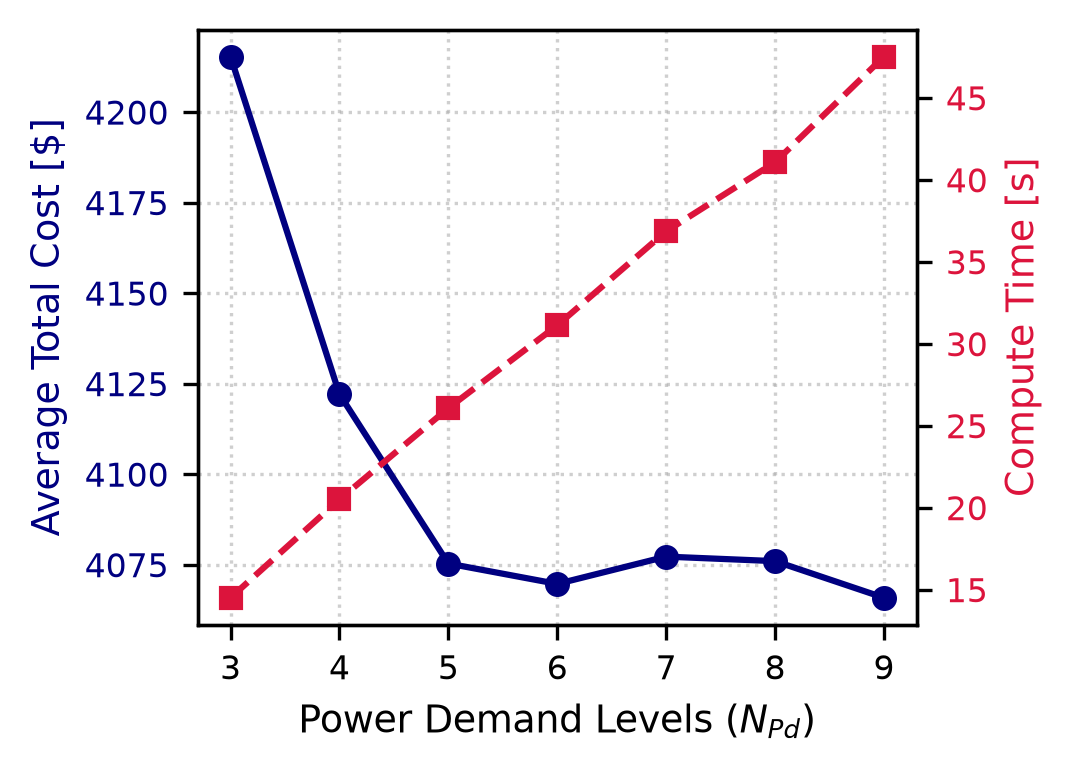

 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 5, 6, 7, 8, 10, 11, 12, 13, 14]


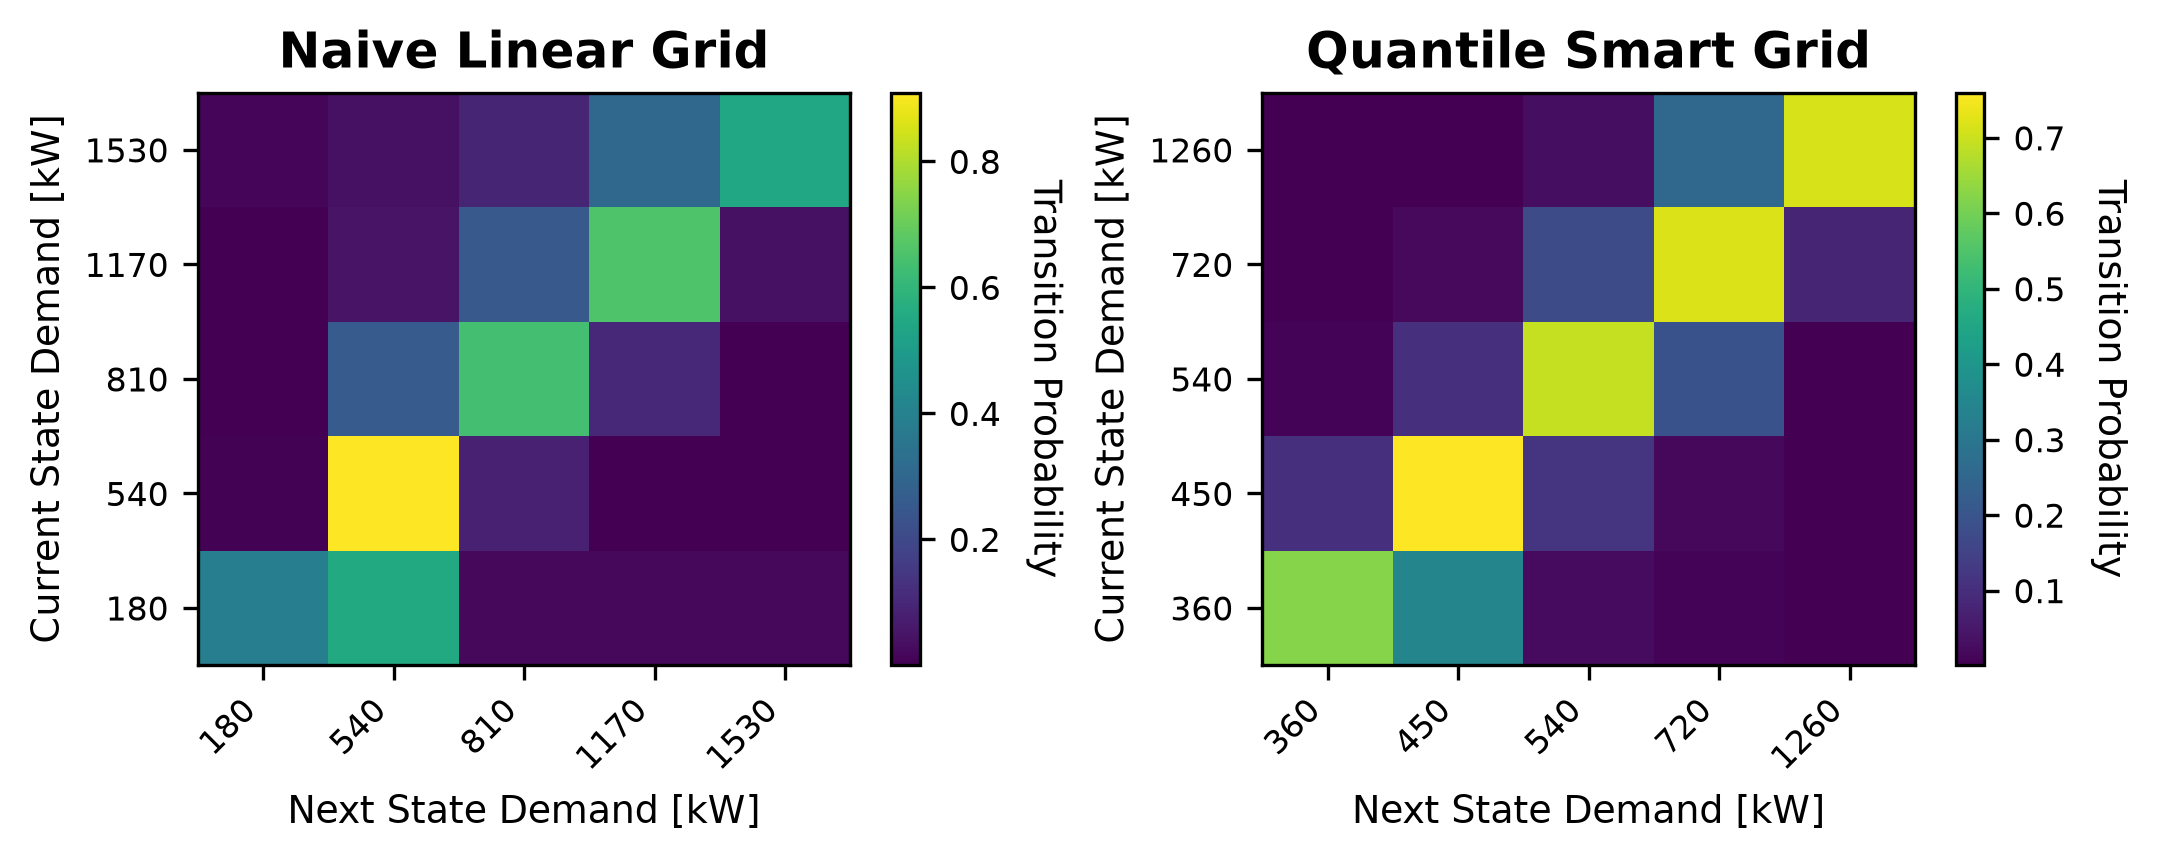

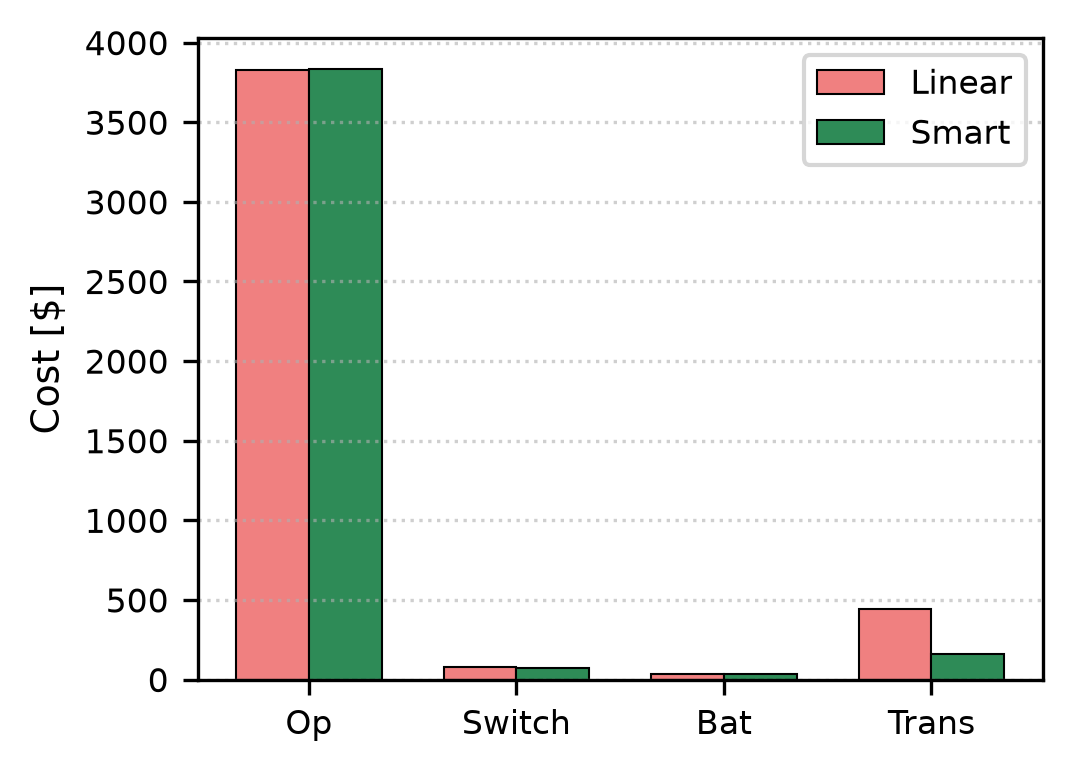

In [9]:
# 4. Publication Visuals
os.makedirs('figures', exist_ok=True)

# ---------------------------------------------------------
# Figure 1: Cardinality L-Curve (Cost vs Compute Time vs N_Pd)
# ---------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(3.5, 2.5))
npd_vals = df_cardinality.index.values
costs_npd = df_cardinality['Total Cost [$]'].values
times_npd = df_cardinality['Offline Compute Time [s]'].values

# Left Axis: Cost (Navy)
color1 = 'navy'
ax1.plot(npd_vals, costs_npd, marker='o', linestyle='-', color=color1, linewidth=1.5, markersize=5)
ax1.set_xlabel('Power Demand Levels ($N_{Pd}$)')
ax1.set_ylabel('Average Total Cost [$]', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(npd_vals)
ax1.grid(True, linestyle=':', alpha=0.6)

# Right Axis: Compute Time (Crimson)
ax2 = ax1.twinx()
color2 = 'crimson'
ax2.plot(npd_vals, times_npd, marker='s', linestyle='--', color=color2, linewidth=1.5, markersize=5)
ax2.set_ylabel('Compute Time [s]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.tight_layout(pad=0.5)
plt.savefig('figures/04_cardinality_lcurve.png')
plt.show()

# ---------------------------------------------------------
# Figure 2: Heatmap Comparison (Double Column Width: 7.16 inches)
# ---------------------------------------------------------
train_sample = [d for d in fleet_data.keys() if d not in exclude_days and d != 9]
mc_s, _, _ = bm_smart._get_or_compute_models(train_sample, None, 1)
mc_l, _, _ = bm_linear._get_or_compute_models(train_sample, None, 1)

fig2, axes = plt.subplots(1, 2, figsize=(7.16, 2.8))
plot_markov_matrix(mc_l, title="Naive Linear Grid", ax=axes[0])
plot_markov_matrix(mc_s, title="Quantile Smart Grid", ax=axes[1])
plt.tight_layout(pad=0.5)
plt.savefig('figures/04_markov_topology_heatmaps.png')
plt.show()

# ---------------------------------------------------------
# Figure 3: Cost Breakdown Bar Chart (Single Column Width: 3.5 inches)
# ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(3.5, 2.5))
metrics = ['Operating Cost [$]', 'Switching Cost [$]', 'Battery Cost [$]', 'Transient Cost [$]']
labels = ['Op', 'Switch', 'Bat', 'Trans']
vals_l = [avg_linear[m] for m in metrics]
vals_s = [avg_smart[m] for m in metrics]

x = np.arange(len(metrics))
w = 0.35
ax3.bar(x - w/2, vals_l, w, label='Linear', color='lightcoral', edgecolor='black', lw=0.5)
ax3.bar(x + w/2, vals_s, w, label='Smart', color='seagreen', edgecolor='black', lw=0.5)
ax3.set_ylabel('Cost [$]')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.legend()
ax3.grid(axis='y', ls=':', alpha=0.6)

plt.tight_layout(pad=0.5)
plt.savefig('figures/04_topology_cost_breakdown.png')
plt.show()